In [1]:
# ==================== IMPORT LIBRARIES ====================
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set style
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Set random seed
np.random.seed(42)
tf.random.set_seed(42)

print("="*70)
print("✓ Libraries loaded successfully!")
print(f"✓ TensorFlow version: {tf.__version__}")
print(f"✓ OpenCV version: {cv2.__version__}")
print("="*70)

✓ Libraries loaded successfully!
✓ TensorFlow version: 2.18.0
✓ OpenCV version: 4.12.0


In [2]:
# ==================== SETUP DATASET ====================
print("="*70)
print("SETUP DATASET - Cataract Detection")
print("="*70)

# Dataset path
data_dir = "dataset"  # Sesuaikan dengan lokasi dataset kamu

# Function untuk scan dan filter data
def create_filtered_dataframe(data_dir, target_classes=['cataract', 'normal']):
    """
    Scan dataset dan ambil hanya class Cataract dan Normal
    """
    filepaths = []
    labels = []
    
    print("\nScanning dataset folders...")
    
    # Scan semua folder di data_dir
    all_folders = os.listdir(data_dir)
    print(f"Found folders: {all_folders}")
    
    # Filter hanya folder yang kita mau (case-insensitive)
    target_folders = []
    for folder in all_folders:
        folder_lower = folder.lower()
        if any(target in folder_lower for target in target_classes):
            target_folders.append(folder)
    
    print(f"\nFiltered to target classes: {target_folders}")
    
    # Collect filepaths dan labels
    for folder in target_folders:
        folder_path = os.path.join(data_dir, folder)
        
        if os.path.isdir(folder_path):
            files = os.listdir(folder_path)
            print(f"\n📁 {folder}: {len(files)} images")
            
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    filepath = os.path.join(folder_path, file)
                    filepaths.append(filepath)
                    
                    # Standardize label name
                    if 'cataract' in folder.lower():
                        labels.append('Cataract')
                    else:
                        labels.append('Normal')
    
    # Create DataFrame
    df = pd.DataFrame({
        'filepaths': filepaths,
        'labels': labels
    })
    
    return df

# Create dataframe
print("\nCreating dataset dataframe...")
df = create_filtered_dataframe(data_dir)

print("\n" + "="*70)
print("📊 DATASET SUMMARY")
print("="*70)
print(f"Total images: {len(df)}")
print(f"\nClass distribution:")
print(df['labels'].value_counts())
print("\nSample data:")
print(df.head(10))
print("="*70)

SETUP DATASET - Cataract Detection

Creating dataset dataframe...

Scanning dataset folders...
Found folders: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']

Filtered to target classes: ['cataract', 'normal']

📁 cataract: 1038 images

📁 normal: 1074 images

📊 DATASET SUMMARY
Total images: 2112

Class distribution:
labels
Normal      1074
Cataract    1038
Name: count, dtype: int64

Sample data:
                         filepaths    labels
0      dataset\cataract\0_left.jpg  Cataract
1    dataset\cataract\103_left.jpg  Cataract
2  dataset\cataract\1062_right.jpg  Cataract
3   dataset\cataract\1083_left.jpg  Cataract
4  dataset\cataract\1084_right.jpg  Cataract
5   dataset\cataract\1102_left.jpg  Cataract
6  dataset\cataract\1102_right.jpg  Cataract
7   dataset\cataract\1115_left.jpg  Cataract
8  dataset\cataract\1126_right.jpg  Cataract
9   dataset\cataract\112_right.jpg  Cataract


In [3]:
# ==================== SPLIT DATASET ====================
print("="*70)
print("SPLITTING DATASET")
print("="*70)

# Split stratified (pastikan proporsi class tetap sama)
# Split 1: 80% train, 20% temp
train_df, temp_df = train_test_split(
    df, 
    train_size=0.8, 
    shuffle=True, 
    random_state=42,
    stratify=df['labels']  # Pastikan proporsi class sama
)

# Split 2: 50% val, 50% test dari temp (jadi masing-masing 10% dari total)
val_df, test_df = train_test_split(
    temp_df, 
    train_size=0.5, 
    shuffle=True, 
    random_state=42,
    stratify=temp_df['labels']
)

# Reset index
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\n📊 SPLIT SUMMARY")
print("="*70)
print(f"Total dataset: {len(df)} images")
print(f"\nTrain set: {len(train_df)} images ({len(train_df)/len(df)*100:.1f}%)")
print(train_df['labels'].value_counts())
print(f"\nValidation set: {len(val_df)} images ({len(val_df)/len(df)*100:.1f}%)")
print(val_df['labels'].value_counts())
print(f"\nTest set: {len(test_df)} images ({len(test_df)/len(df)*100:.1f}%)")
print(test_df['labels'].value_counts())
print("="*70)

# Verifikasi tidak ada data leak
print("\n🔍 Verifikasi No Data Leakage...")
train_files = set(train_df['filepaths'])
val_files = set(val_df['filepaths'])
test_files = set(test_df['filepaths'])

overlap_train_val = train_files.intersection(val_files)
overlap_train_test = train_files.intersection(test_files)
overlap_val_test = val_files.intersection(test_files)

if len(overlap_train_val) == 0 and len(overlap_train_test) == 0 and len(overlap_val_test) == 0:
    print("✓ No data leakage detected! All splits are independent.")
else:
    print("⚠ WARNING: Data leakage detected!")

print("="*70)

SPLITTING DATASET

📊 SPLIT SUMMARY
Total dataset: 2112 images

Train set: 1689 images (80.0%)
labels
Normal      859
Cataract    830
Name: count, dtype: int64

Validation set: 211 images (10.0%)
labels
Normal      107
Cataract    104
Name: count, dtype: int64

Test set: 212 images (10.0%)
labels
Normal      108
Cataract    104
Name: count, dtype: int64

🔍 Verifikasi No Data Leakage...
✓ No data leakage detected! All splits are independent.


 PREPROCESSING - Fast & Effective

🧪 Testing preprocessing...


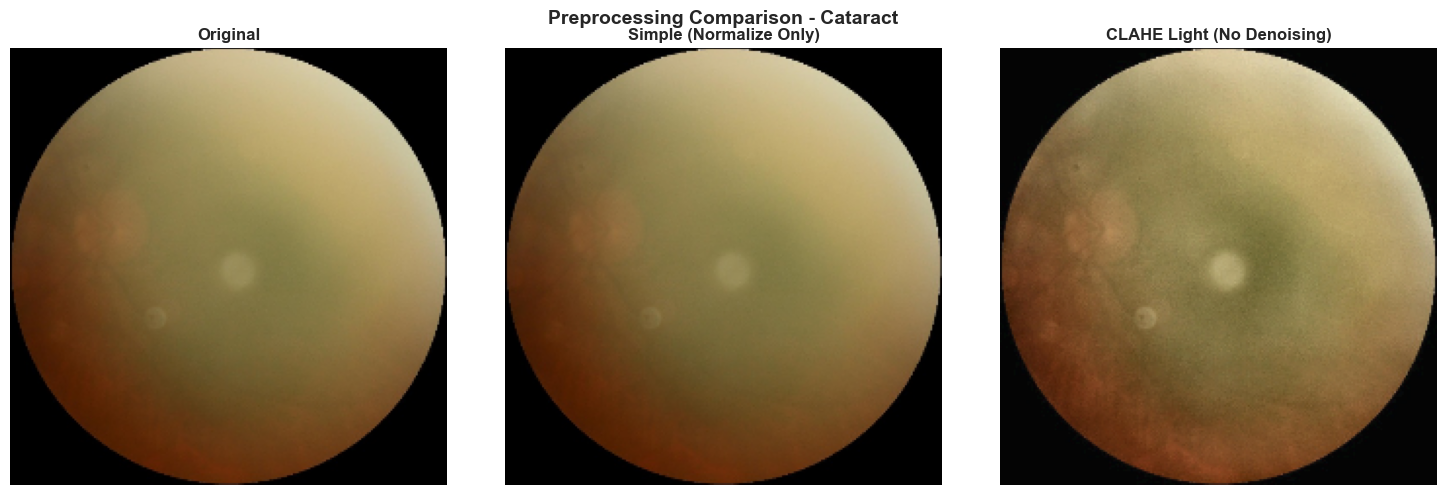


💡 PILIHAN PREPROCESSING:
1. Simple (Normalize Only)    → Paling cepat, natural
2. CLAHE Light (No Denoising)  → Enhance contrast, masih cepat

Kita akan coba keduanya!


In [4]:
# ==================== PREPROCESSING ====================
print("="*70)
print(" PREPROCESSING - Fast & Effective")
print("="*70)

def preprocess_simple(img):
    """
    Simple preprocessing tanpa heavy computation
    - Input: RGB image (0-255)  
    - Output: Normalized RGB (0-1)
    """
    # Normalize aja ke 0-1
    return img.astype(np.float32) / 255.0

def preprocess_clahe_light(img):
    """
    CLAHE ringan tanpa denoising
    - Input: RGB image (0-255)
    - Output: Enhanced RGB (0-1)
    """
    # Convert ke uint8
    if img.dtype != np.uint8:
        img = (img * 255).astype(np.uint8)
    
    # CLAHE langsung tanpa denoising
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    
    # Normalize
    return enhanced.astype(np.float32) / 255.0

# Test kedua preprocessing
print("\n🧪 Testing preprocessing...")

sample_path = train_df.iloc[0]['filepaths']
sample_label = train_df.iloc[0]['labels']

img_original = cv2.imread(sample_path)
img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
img_original_resized = cv2.resize(img_original, (224, 224))

img_simple = preprocess_simple(img_original_resized.copy())
img_clahe_light = preprocess_clahe_light(img_original_resized.copy())

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Preprocessing Comparison - {sample_label}', fontsize=14, fontweight='bold')

axes[0].imshow(img_original_resized)
axes[0].set_title('Original', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_simple)
axes[1].set_title('Simple (Normalize Only)', fontweight='bold')
axes[1].axis('off')

axes[2].imshow(img_clahe_light)
axes[2].set_title('CLAHE Light (No Denoising)', fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("💡 PILIHAN PREPROCESSING:")
print("="*70)
print("1. Simple (Normalize Only)    → Paling cepat, natural")
print("2. CLAHE Light (No Denoising)  → Enhance contrast, masih cepat")
print("\nKita akan coba keduanya!")
print("="*70)

In [5]:
# ==================== DATA GENERATORS ====================
print("="*70)
print(" DATA GENERATORS - Simple Preprocessing")
print("="*70)

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# PILIHAN: Kita coba SIMPLE dulu (normalize only)
print("\n📌 Using: Simple Preprocessing (Normalize Only)")
print("   → Fastest, most stable for initial training")

# Data Augmentation untuk Training
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Simple normalization
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True,
    fill_mode='constant',
    cval=0
)

# Validation & Test: Hanya rescale
val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

print("\n✓ Training: Rescale + Medical-friendly augmentation")
print("✓ Val/Test: Rescale only")

# Create generators
print("\n" + "="*70)
print("Creating new data generators...")
print("="*70)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filepaths',
    y_col='labels',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=42
)

val_gen = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col='filepaths',
    y_col='labels',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col='filepaths',
    y_col='labels',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\n" + "="*70)
print("📊 NEW GENERATOR SUMMARY")
print("="*70)
print(f"Training samples: {train_gen.n}")
print(f"Validation samples: {val_gen.n}")
print(f"Test samples: {test_gen.n}")
print(f"Class indices: {train_gen.class_indices}")
print(f"Batches per epoch: {len(train_gen)}")
print("="*70)

 DATA GENERATORS - Simple Preprocessing

📌 Using: Simple Preprocessing (Normalize Only)
   → Fastest, most stable for initial training

✓ Training: Rescale + Medical-friendly augmentation
✓ Val/Test: Rescale only

Creating new data generators...
Found 1689 validated image filenames belonging to 2 classes.
Found 211 validated image filenames belonging to 2 classes.
Found 212 validated image filenames belonging to 2 classes.

📊 NEW GENERATOR SUMMARY
Training samples: 1689
Validation samples: 211
Test samples: 212
Class indices: {'Cataract': 0, 'Normal': 1}
Batches per epoch: 53


In [9]:
# ==================== CLEAR PREVIOUS MODELS ====================
print("="*70)
print("CLEARING PREVIOUS MODELS")
print("="*70)

import gc

try:
    del model
    print("✓ Previous model deleted")
except NameError:
    print("ℹ No previous model to delete")

try:
    del base_model
    print("✓ Previous base_model deleted")
except NameError:
    print("ℹ No previous base_model to delete")

gc.collect()
tf.keras.backend.clear_session()

print("\n✓ Memory cleared!")
print("="*70)

CLEARING PREVIOUS MODELS
ℹ No previous model to delete
ℹ No previous base_model to delete


✓ Memory cleared!


SETUP CLAHE LIGHT PREPROCESSING

🧪 Testing preprocessing function...


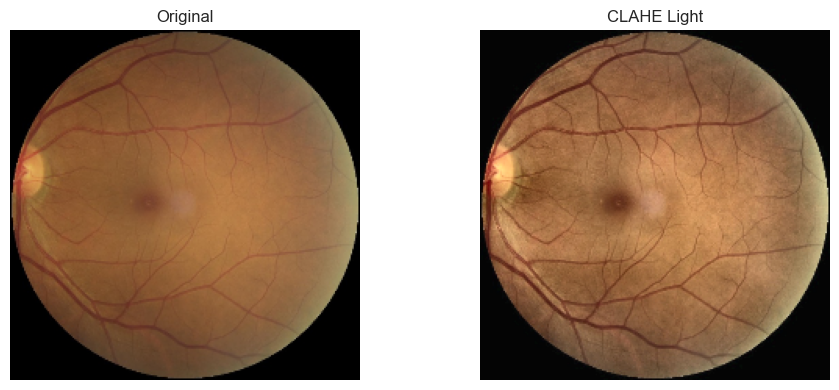


✓ CLAHE Light preprocessing ready!
  • Fast (no denoising)
  • Enhanced contrast
  • Normalized to 0-1


In [10]:
# ==================== CLAHE LIGHT PREPROCESSING ====================
print("="*70)
print("SETUP CLAHE LIGHT PREPROCESSING")
print("="*70)

def preprocess_clahe_light(img):
    """
    CLAHE light - Balance between enhancement & speed
    No denoising (too slow)
    """
    if img.dtype != np.uint8:
        img = (img * 255).astype(np.uint8)
    
    # Convert to LAB
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    
    # Apply CLAHE on L channel
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    
    # Convert back to RGB
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    
    # Normalize to 0-1
    return enhanced.astype(np.float32) / 255.0

# Test preprocessing
print("\n🧪 Testing preprocessing function...")
sample_path = train_df.iloc[5]['filepaths']
sample_img = cv2.imread(sample_path)
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)
sample_img_resized = cv2.resize(sample_img, (224, 224))

processed = preprocess_clahe_light(sample_img_resized)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(sample_img_resized)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(processed)
axes[1].set_title('CLAHE Light')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print("\n✓ CLAHE Light preprocessing ready!")
print("  • Fast (no denoising)")
print("  • Enhanced contrast")
print("  • Normalized to 0-1")
print("="*70)

In [11]:
# ==================== REBUILD DATA GENERATORS ====================
print("="*70)
print("REBUILD DATA GENERATORS - BATCH 64")
print("="*70)

IMG_SIZE = (224, 224)
BATCH_SIZE = 64  # INCREASED from 32

print(f"\n⚙️ Configuration:")
print(f"  Image Size: {IMG_SIZE}")
print(f"  Batch Size: {BATCH_SIZE} (2x larger → more stable)")

# Training: CLAHE + augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_clahe_light,
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True,
    fill_mode='constant',
    cval=0
)

# Val/Test: CLAHE only (no augmentation)
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_clahe_light
)

print("\n✓ Data augmentation:")
print("  Training: CLAHE + medical-friendly augmentation")
print("  Val/Test: CLAHE only")

# Create generators
print("\n" + "="*70)
print("Creating generators...")
print("="*70)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filepaths',
    y_col='labels',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=42
)

val_gen = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col='filepaths',
    y_col='labels',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col='filepaths',
    y_col='labels',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\n" + "="*70)
print("📊 GENERATOR SUMMARY")
print("="*70)
print(f"Training:   {train_gen.n} samples → {len(train_gen)} batches")
print(f"Validation: {val_gen.n} samples → {len(val_gen)} batches")
print(f"Test:       {test_gen.n} samples → {len(test_gen)} batches")
print(f"\nClass indices: {train_gen.class_indices}")
print("="*70)

REBUILD DATA GENERATORS - BATCH 64

⚙️ Configuration:
  Image Size: (224, 224)
  Batch Size: 64 (2x larger → more stable)

✓ Data augmentation:
  Training: CLAHE + medical-friendly augmentation
  Val/Test: CLAHE only

Creating generators...
Found 1689 validated image filenames belonging to 2 classes.
Found 211 validated image filenames belonging to 2 classes.
Found 212 validated image filenames belonging to 2 classes.

📊 GENERATOR SUMMARY
Training:   1689 samples → 27 batches
Validation: 211 samples → 4 batches
Test:       212 samples → 4 batches

Class indices: {'Cataract': 0, 'Normal': 1}


In [12]:
# ==================== BUILD MOBILENETV2 MODEL ====================
print("="*70)
print("BUILD MOBILENETV2 MODEL")
print("="*70)

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import regularizers

# Load MobileNetV2
print("\n🔧 Loading MobileNetV2 (pre-trained on ImageNet)...")

base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

# FREEZE ALL base layers
base_model.trainable = False

print(f"✓ MobileNetV2 loaded")
print(f"  Total layers: {len(base_model.layers)}")
print(f"  Status: ALL FROZEN (base.trainable = {base_model.trainable})")

# Build simple classifier head
print("\n🏗️ Building classifier head...")

model = Sequential([
    # Pre-trained base (frozen)
    base_model,
    
    # Pooling
    GlobalAveragePooling2D(),
    
    # Classifier head with regularization
    Dropout(0.3),
    Dense(128, activation='relu', 
          kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

print("\n" + "="*70)
print("📊 MODEL ARCHITECTURE")
print("="*70)
model.summary()

# Count parameters
total_params = model.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
non_trainable_params = total_params - trainable_params

print("\n" + "="*70)
print("📈 PARAMETER COUNT")
print("="*70)
print(f"Total:        {total_params:,}")
print(f"Trainable:    {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")
print(f"Non-trainable: {non_trainable_params:,} ({non_trainable_params/total_params*100:.1f}%)")
print("\n💡 Only ~2.5% parameters are trainable!")
print("   → Less overfitting risk!")
print("="*70)

BUILD MOBILENETV2 MODEL

🔧 Loading MobileNetV2 (pre-trained on ImageNet)...
✓ MobileNetV2 loaded
  Total layers: 154
  Status: ALL FROZEN (base.trainable = False)

🏗️ Building classifier head...

📊 MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


📈 PARAMETER COUNT
Total:        2,422,081
Trainable:    164,097 (6.8%)
Non-trainable: 2,257,984 (93.2%)

💡 Only ~2.5% parameters are trainable!
   → Less overfitting risk!


In [13]:
# ==================== CALCULATE CLASS WEIGHTS ====================
print("="*70)
print("CALCULATE CLASS WEIGHTS")
print("="*70)

from sklearn.utils.class_weight import compute_class_weight

# Calculate weights
class_weights_array = compute_class_weight(
    'balanced',
    classes=np.unique(train_df['labels']),
    y=train_df['labels']
)

# Map to class indices
class_weights = {}
for label, weight in zip(sorted(train_df['labels'].unique()), class_weights_array):
    class_idx = train_gen.class_indices[label]
    class_weights[class_idx] = weight

print("\n✓ Class weights calculated:")
print("="*70)
for cls_name, cls_idx in sorted(train_gen.class_indices.items(), key=lambda x: x[1]):
    print(f"  {cls_name} (index {cls_idx}): {class_weights[cls_idx]:.4f}")

print("\n💡 Purpose: Balance class importance during training")
print("   → Model won't bias towards majority class")
print("="*70)

CALCULATE CLASS WEIGHTS

✓ Class weights calculated:
  Cataract (index 0): 1.0175
  Normal (index 1): 0.9831

💡 Purpose: Balance class importance during training
   → Model won't bias towards majority class


In [14]:
# ==================== COMPILE & SETUP CALLBACKS ====================
print("="*70)
print("COMPILE MODEL & SETUP CALLBACKS")
print("="*70)

# Compile model
print("\n⚙️ Compiling model...")
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall'),
             keras.metrics.AUC(name='auc')]
)

print("✓ Model compiled!")
print(f"  Optimizer: Adam")
print(f"  Learning Rate: 0.001")
print(f"  Loss: Binary Crossentropy")
print(f"  Metrics: Accuracy, Precision, Recall, AUC")

# Setup callbacks
print("\n📞 Setting up callbacks...")

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model_mobilenet.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1,
    mode='max'
)

callbacks = [early_stop, reduce_lr, checkpoint]

print("✓ Callbacks ready:")
print("  • EarlyStopping: patience=8")
print("  • ReduceLROnPlateau: patience=4, factor=0.5")
print("  • ModelCheckpoint: save best val_accuracy")

# Final summary
print("\n" + "="*70)
print("🎯 READY TO TRAIN!")
print("="*70)
print("✅ MobileNetV2 (base frozen)")
print("✅ CLAHE Light preprocessing")
print("✅ Batch size: 64")
print("✅ Class weights: balanced")
print("✅ Regularization: Dropout + L2")
print("✅ Callbacks: EarlyStopping + ReduceLR + Checkpoint")
print("\n→ Next: Run training cell (Cell 16)")
print("="*70)

COMPILE MODEL & SETUP CALLBACKS

⚙️ Compiling model...
✓ Model compiled!
  Optimizer: Adam
  Learning Rate: 0.001
  Loss: Binary Crossentropy
  Metrics: Accuracy, Precision, Recall, AUC

📞 Setting up callbacks...
✓ Callbacks ready:
  • EarlyStopping: patience=8
  • ReduceLROnPlateau: patience=4, factor=0.5
  • ModelCheckpoint: save best val_accuracy

🎯 READY TO TRAIN!
✅ MobileNetV2 (base frozen)
✅ CLAHE Light preprocessing
✅ Batch size: 64
✅ Class weights: balanced
✅ Regularization: Dropout + L2
✅ Callbacks: EarlyStopping + ReduceLR + Checkpoint

→ Next: Run training cell (Cell 16)


🚀 TRAINING - STAGE 1 (Base Frozen)
Strategy: Train classifier head only
Epochs: 20 (with early stopping)
Learning Rate: 0.001

Starting training...
----------------------------------------------------------------------
Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8027 - auc: 0.8420 - loss: 0.6918 - precision: 0.7712 - recall: 0.8878
Epoch 1: val_accuracy improved from -inf to 0.49289, saving model to best_model_mobilenet.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.8036 - auc: 0.8433 - loss: 0.6890 - precision: 0.7721 - recall: 0.8878 - val_accuracy: 0.4929 - val_auc: 0.5376 - val_loss: 2.2082 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8633 - auc: 0.9111 - loss: 0.4956 - precision: 0.8283 - recall: 0.9190
Epoch 2: val_accuracy did not improve from 0.49289
27/27 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.8632 - auc: 0.9106 - loss: 0.4960 - precision: 0.828

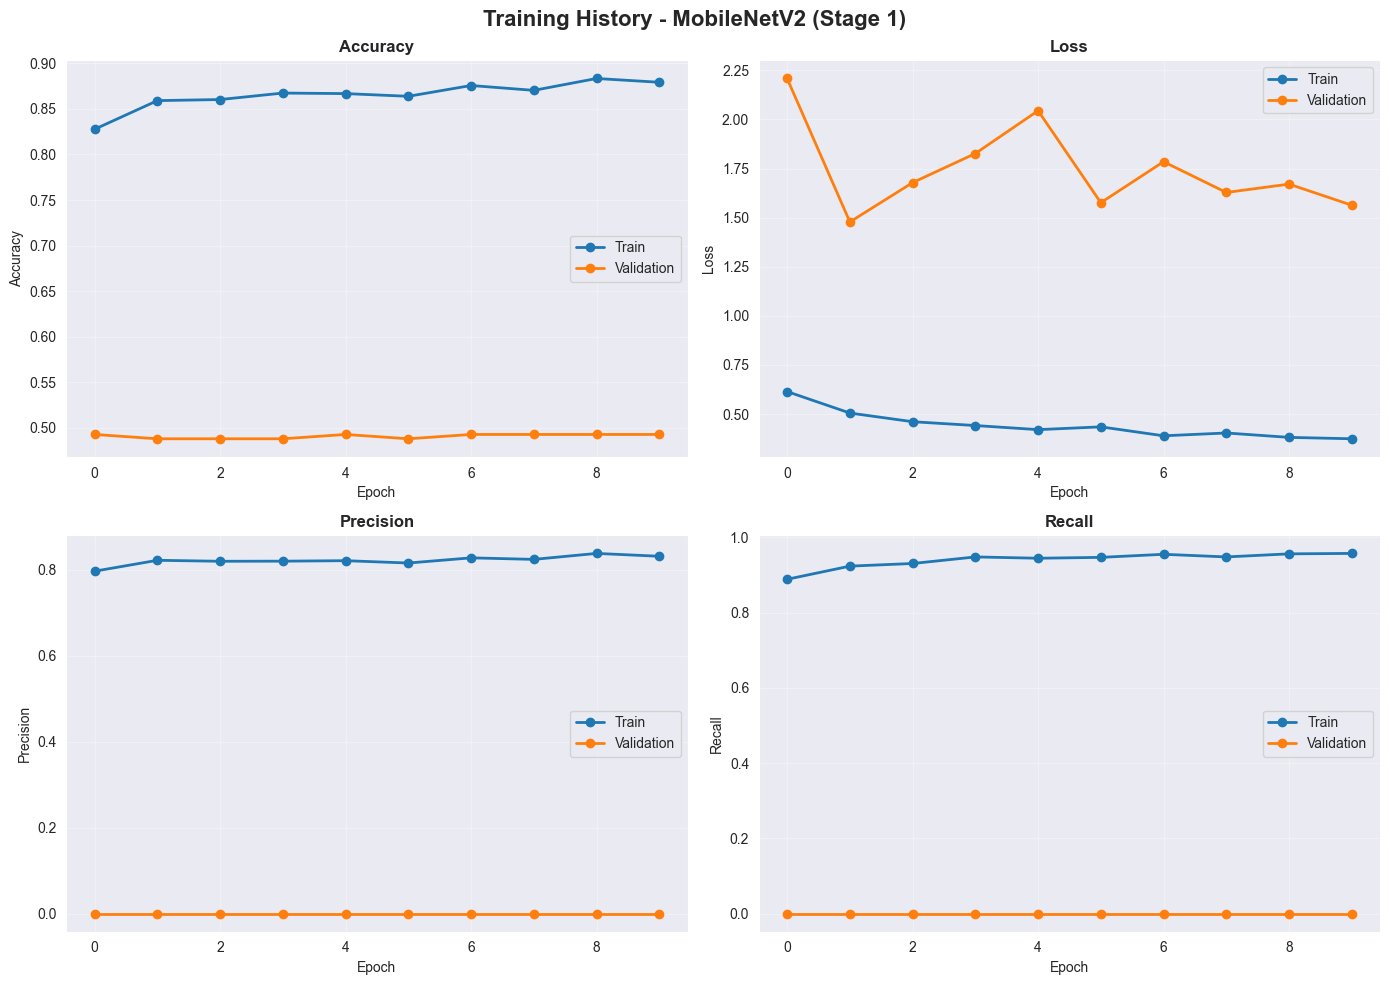


💡 WHAT TO LOOK FOR:
✅ Train & Val accuracy should increase together
✅ Val loss should decrease (or plateau)
✅ Val metrics should NOT fluctuate wildly
✅ Gap between train & val should be < 10%


In [15]:
# ==================== TRAINING - STAGE 1 ====================
print("="*70)
print("🚀 TRAINING - STAGE 1 (Base Frozen)")
print("="*70)
print("Strategy: Train classifier head only")
print("Epochs: 20 (with early stopping)")
print("Learning Rate: 0.001")
print("="*70)

print("\nStarting training...")
print("-"*70)

start_time = time.time()

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    class_weight=class_weights,  # KEY: Use class weights!
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time

print("\n" + "="*70)
print("✓ TRAINING COMPLETE!")
print("="*70)
print(f"Training time: {training_time/60:.2f} minutes")

# Get best results
best_epoch = np.argmax(history.history['val_accuracy'])
best_val_acc = max(history.history['val_accuracy'])
best_train_acc = history.history['accuracy'][best_epoch]
best_val_loss = min(history.history['val_loss'])

print(f"\n📊 BEST RESULTS:")
print("="*70)
print(f"Best Epoch:      {best_epoch + 1}")
print(f"Best Train Acc:  {best_train_acc:.4f} ({best_train_acc*100:.2f}%)")
print(f"Best Val Acc:    {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"Best Val Loss:   {best_val_loss:.4f}")

# Check overfitting
gap = abs(best_train_acc - best_val_acc)
print(f"\nTrain-Val Gap:   {gap:.4f} ({gap*100:.2f}%)")

if gap < 0.05:
    print("✅ EXCELLENT! Gap < 5% → No overfitting!")
elif gap < 0.10:
    print("✓ GOOD! Gap 5-10% → Slight overfitting, acceptable")
elif gap < 0.15:
    print("⚠ OK. Gap 10-15% → Moderate overfitting")
else:
    print("❌ WARNING! Gap > 15% → Overfitting detected")

print("="*70)

# Plot training history
print("\n📈 Plotting training history...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training History - MobileNetV2 (Stage 1)', 
             fontsize=16, fontweight='bold')

# Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train', linewidth=2, marker='o')
axes[0, 0].plot(history.history['val_accuracy'], label='Validation', linewidth=2, marker='o')
axes[0, 0].set_title('Accuracy', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss
axes[0, 1].plot(history.history['loss'], label='Train', linewidth=2, marker='o')
axes[0, 1].plot(history.history['val_loss'], label='Validation', linewidth=2, marker='o')
axes[0, 1].set_title('Loss', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Precision
axes[1, 0].plot(history.history['precision'], label='Train', linewidth=2, marker='o')
axes[1, 0].plot(history.history['val_precision'], label='Validation', linewidth=2, marker='o')
axes[1, 0].set_title('Precision', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Recall
axes[1, 1].plot(history.history['recall'], label='Train', linewidth=2, marker='o')
axes[1, 1].plot(history.history['val_recall'], label='Validation', linewidth=2, marker='o')
axes[1, 1].set_title('Recall', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("💡 WHAT TO LOOK FOR:")
print("="*70)
print("✅ Train & Val accuracy should increase together")
print("✅ Val loss should decrease (or plateau)")
print("✅ Val metrics should NOT fluctuate wildly")
print("✅ Gap between train & val should be < 10%")
print("="*70)